In [1]:
from pathlib import Path 
import sys
import ProbabilisticParcellation.util as ut
import ProbabilisticParcellation.individ_group as ig
import ProbabilisticParcellation.plot as ppp
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import numpy as np
import scipy.stats as ss
import IndividualParcellation.scripts.paths as paths




/Users/callithrix/code/Python/IndividualParcellation/env/lib/python3.9/site-packages/torch/__init__.py:614: UserWarning: torch.set_default_tensor_type() is deprecated as of PyTorch 2.1, please use torch.set_default_dtype() and torch.set_default_device() as alternatives. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/tensor/python_tensor.cpp:453.)
  _C._set_default_tensor_type(t)


## Individual vs. group analysis

To reproduce results, run evaluate_mdtb_rest in scripts.rest.evaluation

In [3]:
base_dir = paths.set_base_dir()
results_dir = paths.set_results_dir(base_dir)
data_dir = paths.set_fusion_dir(base_dir)
Data = pd.read_csv(results_dir + '/evaluation/eval_dcbc_indiv_parcellations_all.tsv', sep='\t')

<Axes: xlabel='type', ylabel='dcbc_group'>

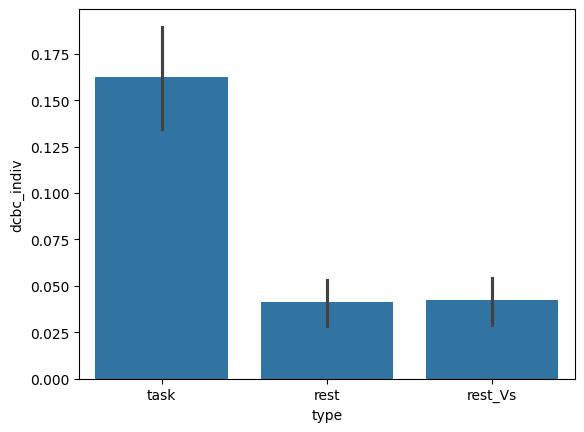

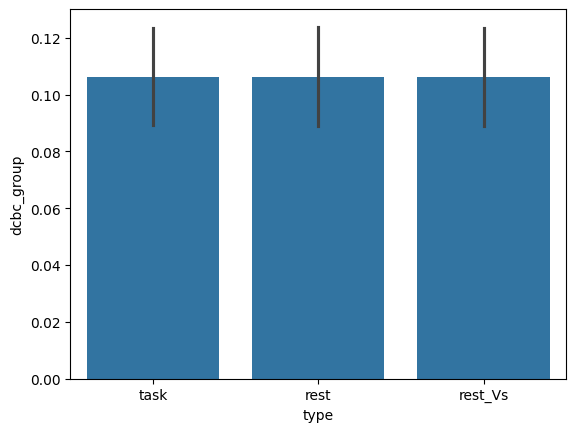

In [14]:
# Seaborn barplot
sb.barplot(x='type', y='dcbc_indiv', data=Data)
plt.figure()
sb.barplot(x='type', y='dcbc_group', data=Data)


In [6]:
# Print mean and sd for each type
print(Data[['type', 'dcbc_indiv', 'dcbc_group']].groupby('type').mean())

         dcbc_indiv  dcbc_group
type                           
rest       0.041462    0.106011
rest_Vs    0.042237    0.106011
task       0.162477    0.106011


In [7]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
participants = T.participant_id
rest_subjects = participants[T['ses-rest'] == 1].tolist()

([<matplotlib.axis.XTick at 0x15d444040>,
 [Text(0, 0, 'sub-02'),
  Text(1, 0, 'sub-03'),
  Text(2, 0, 'sub-06'),
  Text(3, 0, 'sub-08'),
  Text(4, 0, 'sub-10'),
  Text(5, 0, 'sub-12'),
  Text(6, 0, 'sub-14'),
  Text(7, 0, 'sub-18'),
  Text(8, 0, 'sub-20'),
  Text(9, 0, 'sub-22'),
  Text(10, 0, 'sub-24'),
  Text(11, 0, 'sub-25'),
  Text(12, 0, 'sub-26'),
  Text(13, 0, 'sub-27'),
  Text(14, 0, 'sub-28'),
  Text(15, 0, 'sub-30'),
  Text(16, 0, 'sub-31')])

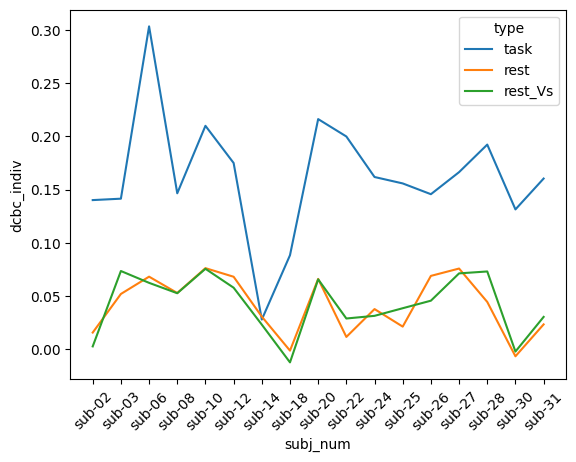

In [8]:
sb.lineplot(x='subj_num', hue='type', y='dcbc_indiv', data=Data)
plt.xticks(ticks=range(len(rest_subjects)), labels=rest_subjects, rotation=45)
